# Assignment 2: Imaging Pipeline

MIDS W281: Computer Vision

## Recommended Libraries

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import os
from glob import glob

## Part 1: Demosaicing

![Bayer Pattern](https://raw.githubusercontent.com/W281/fileRepository/main/Assignments/Assignment_2/bayer_pattern.png)

### Overview
In this exercise you will convert a raw sensor image into a full color image using demosaicing. Digital sensors record color images through a Bayer mosaic (above), where each pixel records only one of the three color colors (RGB). A software interpolation is then needed to reconstruct all three colors at each pixel.

**HINT: There are different Bayer mosaic patterns than the one shown above, so you should look into them if you want the correct setup for Part 1**

### Description: 
We will provide you with some raw images, represented as grayscale images (red, green, and blue pixels are all on the same channel of the image). Your task is to write some python code to demosaic and generate a full three-channel RGB image. You're encouraged to debug your code using the image `signs-small.png` because it is not very large and exhibits some interesting challenges of demosaicing. Note that you may need to convert images between `UINT8` and `float32` data types for computation and visualization.

For simplicity we will ignore the pixels at the boundary of the image, specifically the first and last two rows and columns don't need to be reconstructed. This will allow you to focus on the general case and not worry about whether neighboring values are unavailable. It's actually not uncommon for cameras and software to return a slightly-cropped image for similar reasons. Therefore, for an image of size NxN, you will return a cropped image of size (N-2)x(N-2)x3.  

1. Write a python function that takes as input a raw image and offset and returns a single-channel 2-D image corresponding to the interpolated green channel. The offset encodes whether either the top-left pixel or its right neighbor is the first green pixel. In our Figure 1 example, the second pixel is green, so offset=1.  

2. Write another python function for generating the red and blue channels. This function takes a raw image and two offsets: one for row offset and one for column offset, and returns a single-channel image. The row/column offset for the red channel is (0,0) and for the blue channel (1,1) for the Figure 1 example, but that might not be the case for the signs images (see hint). Note that the interpolation for the red/blue channel will be different than the green channel because the recorded pixels are sparser. For interpolated pixels that have two direct neighbors that are known (left-right or up-down), simply take the linear average between the two values. For the remaining case, average the four diagonal pixels. You can ignore the first and last two rows or columns to make sure that you have all the neighbors you need. Similar to the green-channel, interpolate the values when they are missing and copy the values when they are available.  

3. Using the above two functions, create a full three-channel, RGB image. You might observe some checkerboard artifacts around strong edges. This is expected from our naive interpolation approach.

### Deliverables:
- Python code for interpolation of green channel and red/blue channel that handles different Bayer mosaic patterns dictated by the offsets
- Full-three channel RGB image for `signs.png` (**THE BIG ONE, NOT THE SMALL ONE**)

I first wrote a helper function to make the interpolation easier later on. It computes the mean for an arbitrary subset of the immediate neighbors of a pixel, so that we can easily apply it to the orthogonal, diagonal, horizontal and vertical cases.

In [2]:
# Maps to the RELATIVE position of neighbor in each direction
# In the coordinates of the ORIGINAL image (before boundary crop)
NEIGHBOR_POINTERS = {
    'NW': (0, 0), 'N' : (0, 1), 'NE': (0, 2),
    'W' : (1, 0),               'E' : (1, 2),
    'SW': (2, 0), 'S' : (2, 1), 'SE': (2, 2),
}

def get_mean_of_neighbors(
    raw_img: np.ndarray, 
    i: int, j: int, 
    directions: set[str],
) -> float:
    """
    Helper function to retrieve the mean of a subset of a pixel's neighbors.
    
    EXAMPLES:
    directions={N,  S,  E,  W } uses the four orthogonally adjacent pixels' values.
    directions={NW, NE, SW, SE} looks only at diagonal pixels' values.
    """
    assert len(directions) > 0, "Set of directions is empty!"
    neighbor_values = []

    for key in directions:
        neighbor_coords = np.array([i, j]) + np.array(NEIGHBOR_POINTERS[key])
        neighbor_values.append(raw_img[*neighbor_coords])

    return np.mean(neighbor_values)

In [3]:
def interpolate_green(raw_img: np.ndarray, offset_value: int) -> np.ndarray:
    
    # Initialize green array and clip the boundary
    green_img = np.empty_like(raw_img[1:-1, 1:-1])
    num_rows, num_cols = green_img.shape

    # Clipping boundary flips the offset value
    offset_value = int(not bool(offset_value))

    ORTHOGONAL_NEIGHBORS = {'N', 'S', 'E', 'W'}

    # Iterate over all pixels in the new image
    for i in range(num_rows):
        for j in range(num_cols):

            # This means the pixel is green: should just copy the pixel value
            if (i - j) % 2 == offset_value: green_img[i, j] = raw_img[i + 1, j + 1]

            else:
                # Interpolate using the mean of 4 orthogonally adjacent pixels
                green_img[i, j] = get_mean_of_neighbors(raw_img, i, j, ORTHOGONAL_NEIGHBORS)
    
    return green_img

In [4]:
def interpolate_redblue(raw_img: np.ndarray, offset_pair: tuple) -> np.ndarray:

    row_offset, col_offset = offset_pair
    
    # Clipping boundary flips the offset value(s)
    row_offset = int(not bool(row_offset))
    col_offset = int(not bool(col_offset))

    # Initialize red/blue array and clip the boundary
    redblue_img = np.empty_like(raw_img[1:-1, 1:-1])
    num_rows, num_cols = redblue_img.shape

    # Iterate over all pixels in the new image
    for i in range(num_rows):
        for j in range(num_cols):

            in_row = (i % 2) == row_offset
            in_col = (j % 2) == col_offset

            # This means the pixel is the intended color: should just copy the pixel value
            if in_row and in_col: 
                redblue_img[i, j] = raw_img[i + 1, j + 1]

            # If cell is in the right row but not the intended color, interpolate horizontally
            elif in_row:
                redblue_img[i, j] = get_mean_of_neighbors(raw_img, i, j, {'W', 'E'})

            # If cell is in the right column but not the intended color, interpolate vertically
            elif in_col:
                redblue_img[i, j] = get_mean_of_neighbors(raw_img, i, j, {'N', 'S'})

            else:
                # Interpolate using the mean of 4 diagonal pixels
                redblue_img[i, j] = get_mean_of_neighbors(raw_img, i, j, {'NW', 'NE', 'SW', 'SE'})
    
    return redblue_img

In [5]:
def demosaic(
    raw_img: np.ndarray,
    green_offset: bool,
    red_row_offset: bool,
) -> np.ndarray:
    "Given a raw sensor image and two Bayer offsets, demosaics the image and returns a cropped RGB version."

    img = raw_img.copy()
    red_col_offset = (red_row_offset == green_offset)

    # Perform interpolation within each channel
    green_img = interpolate_green(img, green_offset)
    red_img   = interpolate_redblue(img, (    red_row_offset,     red_col_offset))
    blue_img  = interpolate_redblue(img, (not red_row_offset, not red_col_offset))
    
    # Append individual channels into one color image, with values encoded as INT8
    return np.stack((red_img, green_img, blue_img), axis=-1)

Above, I wrapped the entire demosaic procedure into its own function so it'd be easier to sweep over the different Bayer patterns. I applied each of the four possible setups to the test image top see which fit best.

The image is an instance of <class 'numpy.ndarray'> and its entries are stored as float32.
GREEN: 0 | RED: 0


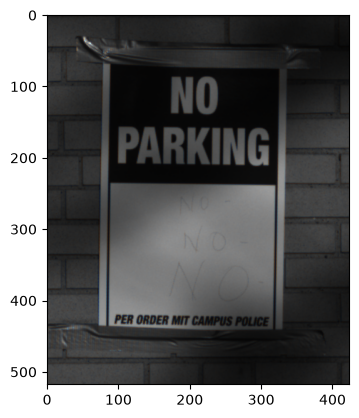

GREEN: 0 | RED: 1


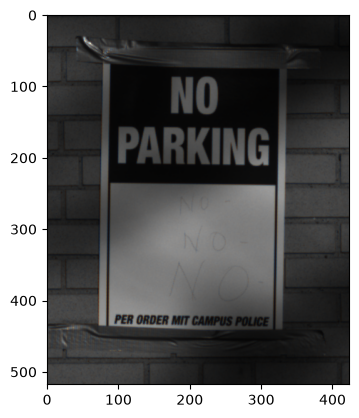

GREEN: 1 | RED: 0


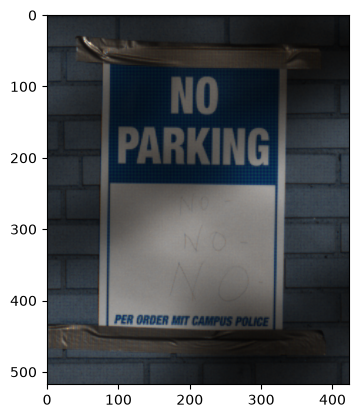

GREEN: 1 | RED: 1


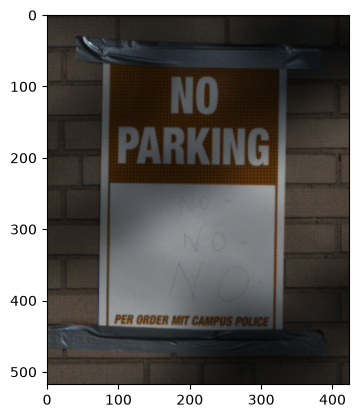

In [6]:
test_img = plt.imread('./demosaicing/signs-small.png')

img = test_img.copy()
print(f'The image is an instance of {type(img)} and its entries are stored as {img.dtype}.')

for green_offset in [0, 1]:
    for red_offset in [0, 1]:
        print(f'GREEN: {green_offset} | RED: {red_offset}')
        
        color_img = demosaic(img, green_offset, red_offset)

        plt.imshow(color_img)
        plt.show()

The bottom version (parameterized as 1,1 in my approach) was the only one to add an appreciable red hue to both the parking sign and the bricks behind it, so I deduced that was the correct setting. I then applied that filter to the full-size image below, and again we see that the DANGER sign is appropriately red.

The image is an instance of <class 'numpy.ndarray'> and its entries are stored as float32.


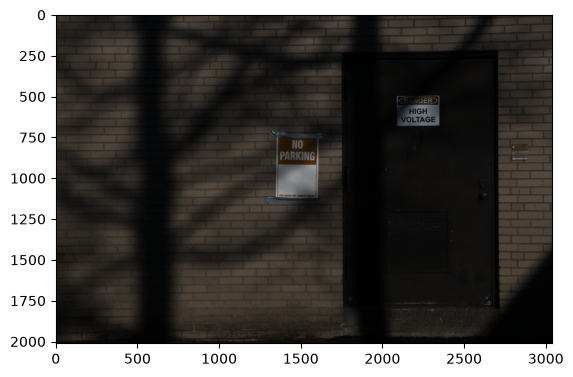

In [7]:
# Load image into memory and create copy
raw_img = plt.imread('./demosaicing/signs.png')
img = raw_img.copy()
print(f'The image is an instance of {type(img)} and its entries are stored as {img.dtype}.')

# Use the previous offsets to demosaic
color_img = demosaic(img, 1, 1)

plt.imshow(color_img)
plt.show()

## Part 2: Denoising

![Denoising Teaser](https://raw.githubusercontent.com/W281/fileRepository/main/Assignments/Assignment_2/denoising.png)

### Overview
Random noise is a problem that often arises in cameras specially in extremely low light conditions, and its presence can seriously degrade the quality of a digital image. To remedy the situation, an average of multiple images, captured very close in time, can be used to improve the quality final image. Because the camera may move while recording mulitple images, we will need to align the images before averaging and denoising. We will implement this alignment + denoising algorithm.

### Description: 
We provide 18 images captured in a low light setting. One of the images is shown above.

Each image is slightly mis-aligned from the previous image in the sequence. Our goal is to align each of the images in the sequence to the first image and then average the aligned images to reduce the noise (which tends to be independent across images). Note that you may need to convert images between `UINT8` and `float32` data types for computation and visualization.

1. Write a python function that takes as input two images and returns the horizontal and vertical offset that best aligns the two images. Ignore the difference for all the pixels less than or equal to a `maxOffset` away from the edges. Use a brute force approach that tries every possible integer translation and evaluates the quality of a match using the squared error norm (the sum of the squared pixel differences). You can set the `maxOffset` to 15 pixels.  
2. Align each image to the first image and denoise by averaging all of the aligned images.

**HINT: sweeping through all of the offsets means more than just going right and down**

### Deliverables:

- Python code to align noisy images
- Aligned and de-noised average image

In [8]:
def align_imgs(img1: np.ndarray, img2: np.ndarray, max_offset: int) -> tuple:
    img_h, img_w, _ = img2.shape
    
    assert max_offset > 0
    best_offset = None
    best_error  = np.inf

    def cropped_sq_err(shifted: np.ndarray) -> float:
        "Helper function to compute squared-error norm between the cropped images."
        # Only consider pixels max_offset from the boundary
        cropped_reference = img1   [max_offset:-max_offset, max_offset:-max_offset]
        cropped_shifted   = shifted[max_offset:-max_offset, max_offset:-max_offset]
        return np.sum((cropped_shifted - cropped_reference) ** 2)

    offsets = range(-max_offset, max_offset + 1)
    for x in offsets:
        for y in offsets:
            # Shift the image by current offset and compute error
            shifted = np.roll(img2,    shift=x, axis=0)
            shifted = np.roll(shifted, shift=y, axis=1)
            sq_err  = cropped_sq_err(shifted)

            if sq_err < best_error:
                best_error  = sq_err
                best_offset = (x, y)
    
    return best_offset, best_error

In [9]:
def combine_imgs(img_list: list[np.ndarray]) -> np.ndarray:
    """
    Denoises an image by aligning each image in the list to the 
    first, then averaging all pixel values over all the images.
    """
    
    num_imgs      = len(img_list)
    first_img     = img_list.pop(0)
    composite_img = first_img.copy()

    for idx, img in enumerate(img_list):
        # Brute-force search for the optimal offset
        best_offset, _ = align_imgs(first_img, img, 15)

        print(f'Image {idx+1}/{num_imgs-1}: Best offset is ({best_offset[0]}, {best_offset[1]})')

        # Apply the best offset to the current image
        shifted = np.roll(img,     shift=best_offset[0], axis=0)
        shifted = np.roll(shifted, shift=best_offset[1], axis=1)

        composite_img += shifted # Maintain running sum of pixel values
        
    return composite_img / num_imgs

Image 1/17: Best offset is (0, 4)
Image 2/17: Best offset is (0, 15)
Image 3/17: Best offset is (1, 12)
Image 4/17: Best offset is (1, 9)
Image 5/17: Best offset is (2, 6)
Image 6/17: Best offset is (1, 6)
Image 7/17: Best offset is (3, 1)
Image 8/17: Best offset is (1, 8)
Image 9/17: Best offset is (1, 8)
Image 10/17: Best offset is (0, 8)
Image 11/17: Best offset is (1, 1)
Image 12/17: Best offset is (5, -3)
Image 13/17: Best offset is (6, -8)
Image 14/17: Best offset is (4, -5)
Image 15/17: Best offset is (6, -5)
Image 16/17: Best offset is (8, -2)
Image 17/17: Best offset is (8, -4)


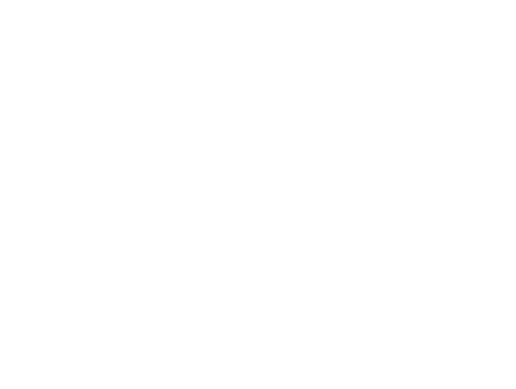

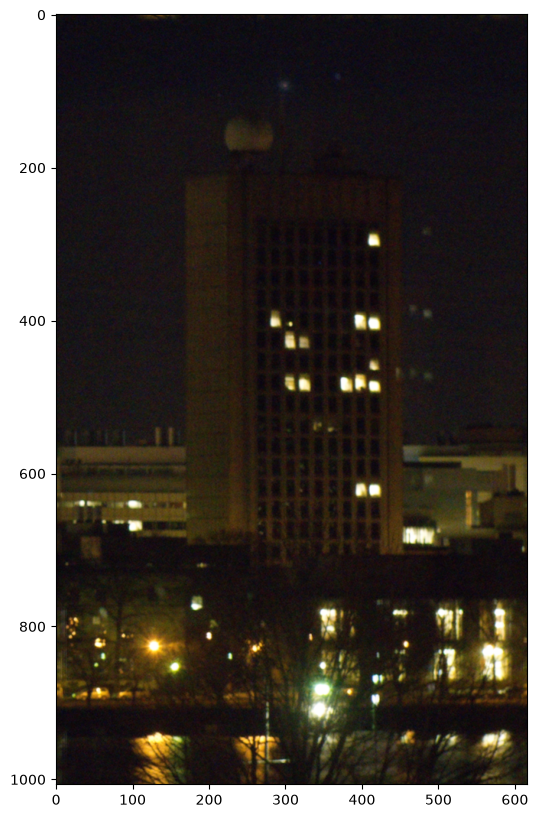

In [10]:
# Load images into memory
img_paths = sorted(glob('./denoising/*.png'))
img_list = [plt.imread(path).astype(np.float32) for path in img_paths]

composite_img = combine_imgs(img_list)

plt.axis('off')
plt.figure(figsize = (10,10))
plt.imshow(composite_img)
plt.show()

## Part 3: White balance

Before WB

![WB Teaser](https://raw.githubusercontent.com/W281/fileRepository/main/Assignments/Assignment_2/white_balance/input.png)

After WB Gray-world

![WB Teaser](https://raw.githubusercontent.com/W281/fileRepository/main/Assignments/Assignment_2/white_balance/output.png)

After WB White-patch

![WB Teaser](https://raw.githubusercontent.com/W281/fileRepository/main/Assignments/Assignment_2/white_balance/output_wp.png)

### Overview
Color constancy is one of the most amazing features of the human visual system. When we look at objects under different illuminations, their colors stay relatively constant. This helps humans to more easily identify objects under varying illuminations. A similar behavior is highly desirable in digital still and video cameras. This is achieved via white balancing, typically employed in a digital camera's imaging pipeline to adjust the coloration of images captured under different illuminations.

### Description 
You will implement two methods for white balancing, gray-world and white-patch, described below. The two images above show before and after white balancing using the gray-world assumption. You can test your white balancing code using this example image. Images which are white-balanced using the white-patch method will have a different appearance depending on the patch selected.

1. One simple technique for white balancing is based on the gray-world assumption. This assumption argues that the average reflectance of a scene is achromatic. In other words, the mean of the red, green, and blue channels in a given scene should be roughly equal. We will implement this white balancing technique. Write a function to automatically white balance an image using the gray-world assumption. You should multiply each color channel by a scale factor so that the resulting mean of each of the three color channels is the same and equal to the average value of the green channel of the input image.

2. Another method for white balancing uses a white-patch in the image. In this method, the user manually selects an image region which is supposed to be white but looks colored due to the scene illumination. As above, we will scale each color channel by a factor so that the average color of the selected region becomes white. Write a python code to implement the white-patch balancing method. Your code should take in a location in the image and use a fixed-sized region around that point to compute the target white point.  You will know your output is correct if things that are supposed to be white look more white (e.g. clouds).

In both cases, you will need to account for pixel values that fall outside the displayable range after transformation. You should clip these values rather than scaling them.

Please specify the region that you selected in your code for 2.

### Deliverables:

- Python functions for gray-world and white-patch white balancing
- Output images after white balancing the image `white_balance/input.png` using both gray-world and white-patch methods

In [14]:
def gray_world(input_img: np.ndarray) -> np.ndarray:
    """
    White balances an image by scaling red and blue pixels such 
    that their mean matches the mean value of all green pixels.
    """
    wb_img = input_img.copy()[:, :, :3] # RGBA -> RGB

    # Compute means within each channel and compute scaling factors
    mean_by_channel = np.mean(wb_img, axis=(0, 1))
    scaling_factors = mean_by_channel / mean_by_channel[2]

    # Scale and clip within each channel
    wb_img /= scaling_factors
    wb_img = np.clip(wb_img, a_min=0.0, a_max=1.0)
    
    return wb_img

In [12]:
def white_patch(
    input_img: np.ndarray, 
    center_coords: tuple[int, int],
    patch_radius: int = 5,
) -> np.ndarray:
    """
    Given an image and a square region of that image (indexed by a central point 
    and radius), scales color values so that that region is white on average.
    """
    wb_img = input_img.copy()
    img_h, img_w, _ = input_img.shape

    # Compute bounds in each dimension based on center + radius
    # Check for out-of-bounds explicitly, clip to within picture
    x_min = max(center_coords[0] - patch_radius, 0)
    x_max = min(center_coords[0] + patch_radius, img_w)
    y_min = max(center_coords[1] - patch_radius, 0)
    y_max = min(center_coords[1] + patch_radius, img_h)

    patch_means_by_channel = np.mean(
        input_img[y_min:y_max+1, x_min:x_max+1],
        axis=(0,1),
    )
    scale_factors = 1.0 / patch_means_by_channel

    # Scale and clip within each channel
    wb_img = wb_img * scale_factors
    wb_img = np.clip(wb_img, a_min=0.0, a_max=1.0)
    
    return wb_img

For the white-patch balancing, I parameterized the user-selected region in my code by passing a center (in pixel coordinates) and radius around that center (also in pixels). That way I could easily select a square from the image. Like was mentioned in the problem statement, I figured the clouds on the horizon were the most likely to be white, so I opened the image in a photo editor and picked out (229, 98) as a reasonable center of the cloudy region. I set the radius to 5, thus selecting an 11x11 square within the cloud as the white patch.

The image is an instance of <class 'numpy.ndarray'> and its entries are stored as float32.


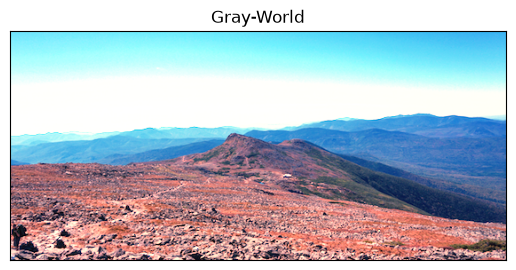

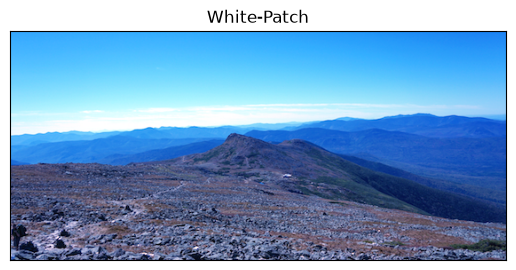

In [13]:
# Load image
input_img = plt.imread('./white_balance/input.png')
print(f'The image is an instance of {type(input_img)} and its entries are stored as {input_img.dtype}.')

gray_world_output  = gray_world (input_img)
white_patch_output = white_patch(input_img, (229, 98))

fig1 = plt.figure()
plt.imshow(gray_world_output)
plt.xticks(ticks=[])
plt.yticks(ticks=[])
plt.title('Gray-World')
plt.show()

fig2 = plt.figure()
plt.imshow(white_patch_output)
plt.xticks(ticks=[])
plt.yticks(ticks=[])
plt.title('White-Patch')
plt.show()

#### Acknowledgments
This assignment is based on an assignment for Computational Aspects of Digital Photography class by Prof. Wojciech Jarosz at Dartmouth College.